In [17]:
#!pip install darts

In [18]:
import yfinance as yf
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.utils.statistics import plot_acf, plot_pacf
from darts.models import ARIMA
import matplotlib.pyplot as plt

In [19]:
from tqdm.auto import tqdm
for i in tqdm(range(100)):
    pass


100%|██████████| 100/100 [00:00<?, ?it/s]


In [20]:
tesla_data = yf.download(
    'TSLA',
    start='2014-01-01',
    end='2023-11-01',
    interval='1mo',
    progress=False,
    auto_adjust=False#cambio en el comportamiento de yfinance a futuro.
)
tesla_data = tesla_data['Close']  # Nos enfocamos en los precios de cierre

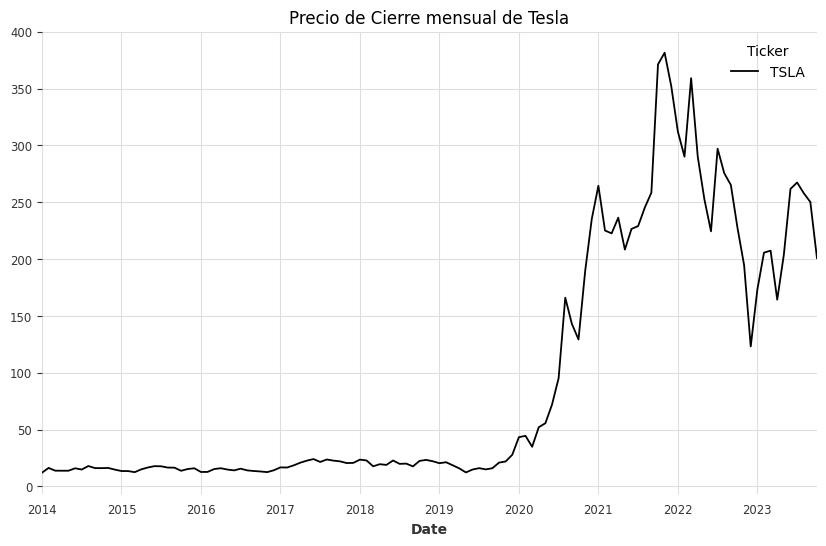

In [21]:
tesla_data.plot(figsize=(10, 6))
plt.title('Precio de Cierre mensual de Tesla')
plt.show()#Gráficamente notamos que no es estacionaria

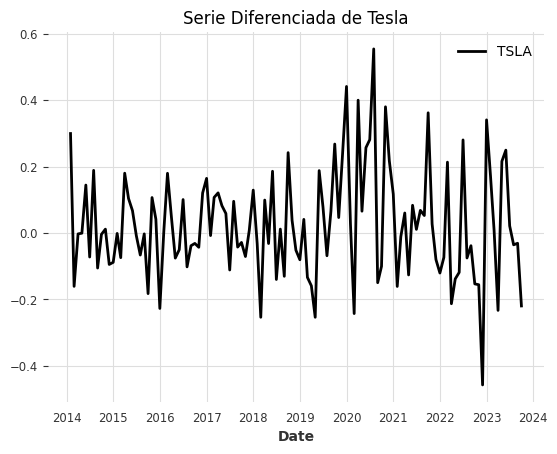

In [22]:
# Aplicando el logaritmo usando NumPy
tesla_log_data = np.log(tesla_data)#Aplicar log para controlar la varianza de la serie

tesla_log_data = tesla_log_data.squeeze()  # convierte DataFrame (1 col) en Series

# Convirtiendo de nuevo a TimeSeries de Darts
tesla_log_ts = TimeSeries.from_series(tesla_log_data, fill_missing_dates=True)

# Diferenciando la serie logarítmica
tesla_diff = tesla_log_ts.diff()#Para eliminar tendencia

tesla_diff.plot()
plt.title('Serie Diferenciada de Tesla')
plt.show()
#Visualmente, vemos que tiene un comportamiento estacionario: media constante y varianzas -considerablemente- controladas.

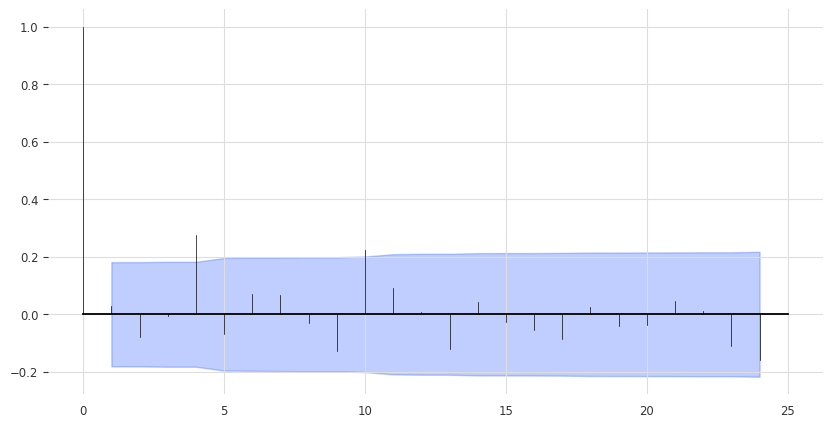

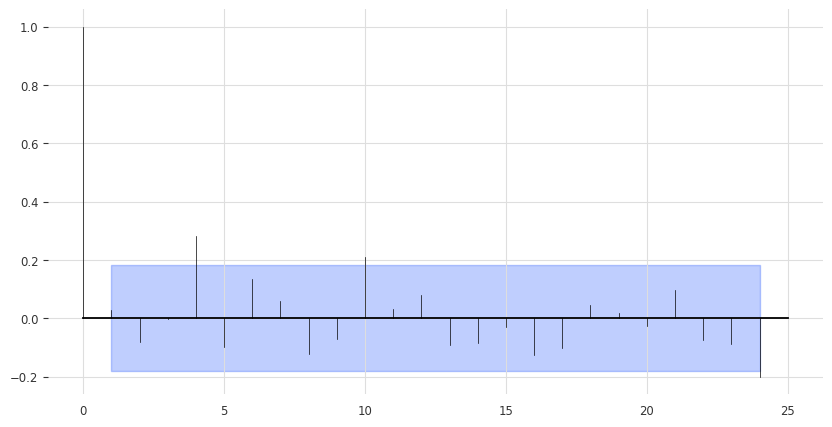

In [23]:
# Graficar ACF
plot_acf(tesla_diff)#Sin decaimiento, casi dentro de zona azul (execto lag 4 y 10)
# Graficar PACF
plot_pacf(tesla_diff)#Sin decaimiento, casi dentro de zona azul (execto lag 4 y 10)
##Recordemos que por principio parsimonia, entre más sencillo el modelo, mejor. 
##Por ello ya que el impacto demandaría hasta diez nuevas variables y eso sería complicar mucho el modelo

In [24]:
import pmdarima as pm

# Convierte la serie temporal de Darts a una serie de pandas
#tesla_diff_pd = tesla_diff.pd_series() ELLOS TENÍAN

tesla_diff_pd = pd.Series(
    tesla_diff.values().flatten(),   # vector de valores
    index=tesla_diff.time_index      # índice datetime
)

import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    # Ajusta el modelo ARIMA utilizando auto_arima
    auto_model = pm.auto_arima(#ajustar muchos modelos ARMA, para elegir al mejor modelo ARMA en base a algún criterio. 
        tesla_diff_pd,
        seasonal=False,#No estamos asumiendo que hay una componente estaciona
        stepwise=False,
        suppress_warnings=True,
        rror_action="ignore",
        max_order=None,
        trace=True,#Imprime todos los modelos que está ajustando y sus respectivos valores
        start_p =0 , max_p = 4,
        start_q=0 , max_q=4)


# Obtén el AIC del modelo ajustado
aic_value_auto = auto_model.aic()
print(f'AIC auto modelo: {aic_value_auto}')#AIC es el coeficiente de información de Akaike, dice qué tan bueno es el modelo ajustado
#un buen modelo es el que tiene el menor número real de AIC

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-86.433, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-84.742, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-82.982, Time=0.04 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-81.038, Time=0.09 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=-92.346, Time=0.13 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-84.704, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-83.891, Time=0.11 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-80.984, Time=0.11 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-84.876, Time=0.19 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=-90.399, Time=0.21 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-83.140, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-81.146, Time=0.11 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-82.009, Time=0.21 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-90.595, Time=0.25 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=-89.425, Time=0.33 sec
 ARIMA(3,0,0)(0,0,0)[0]  

In [25]:
# Obtén los parámetros estimados del modelo seleccionado
estimated_params = auto_model.arima_res_.params
print(f'Parámetros estimados: {estimated_params}')

Parámetros estimados: ma.L1     0.068013
ma.L2    -0.017649
ma.L3    -0.051494
ma.L4     0.355978
sigma2    0.024292
dtype: float64


La ecuación para $X_t$ es:

$$X_t = \epsilon_t + 0.068013 \cdot \epsilon_{t-1} - 0.017649 \cdot \epsilon_{t-2} - 0.051494 \cdot \epsilon_{t-3} + 0.355978 \cdot \epsilon_{t-4}$$
donde $\epsilon_{t} \sim RB(0, 0.024292)$ y $X_t = log(Y_t) - log(Y_{t-1})$ e $Y_t$ es el valor del precio de la acción de Tesla en el mes $t$

In [26]:
tesla_data.tail()

Ticker,TSLA
Date,
2023-06-01,261.769989
2023-07-01,267.429993
2023-08-01,258.079987
2023-09-01,250.220001
2023-10-01,200.839996


# 📌 Ejemplo concreto con números

log_Y_last = np.log([200.839996])        # log del último valor real
future_diff_preds = np.array([0.02, -0.01, 0.03])

np.cumsum(future_diff_preds)      # → [0.02, 0.01, 0.04]

log_Y_preds = log_Y_last + np.cumsum(future_diff_preds)
# → [log(200.83)+0.02, log(200.83)+0.01, log(200.83)+0.04]

In [27]:
import numpy as np

# Suponiendo que model es tu modelo ARIMA ajustado
# y que Y_last es el último valor observado de Y_t

# Predice la serie diferenciada X_t para los próximos n periodos
future_diff_preds = auto_model.predict(n_periods=1)

# Integra las predicciones diferenciadas para obtener
# las predicciones del logaritmo de Y_t
log_Y_last = np.log([200.839996])
log_Y_preds = log_Y_last + np.cumsum(future_diff_preds)#cambios acumulados predichos por el modelo

# Exponencia las predicciones del logaritmo de Y_t
# para obtener las predicciones de Y_t
Y_preds = np.exp(log_Y_preds)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [28]:
Y_preds

2023-11-01    196.38033
Freq: MS, dtype: float64